# Introduction

In this quickstart demo, we'll be walking through some of the capabilities of the `numcompute` library. 

### 1. Simple ML Preprocessing pipeline demo (`io`, `preprocessing`, `pipline`):
1. Read a csv file into a NumPy `ndarray` then separate the data into numerical and categorical features. 
1. For the numerical features, we'll set up a `Pipeline` to replace missing values using the `SimpleImputer` and then use `StandardScaler` to scale the values so that each feature has a mean of `0` and a standard deviation of `1`. 
1. The categorical features will be passed through the `OneHotEncoder` and turned into a numerical one-hot array. 
1. The preprocessed arrays will then be combined into data ready for an ML model.

### 2. `sort_search` and `rank` demo
Using the sorting, searching and ranking functions, we look for interesting data points in the sample temperature data.

### 3. `stats` demo
The `stats` module provides a memerory-efficient mechanism to calculate key statistical attributes of streamed data. We feed the sample temperature data into the Statistics class to show this in action.


### 4. `optim` demo
The optim library contains functions that can be used in model training. The functions calculate a numerical approximation of partial derivatives using finite differences, informing how to adjust model weights in gradient descent. We create some simple function to demonstrate how to use `grad()` (scalar-returning functions) and `jacobian()` (vector-returning functions).


### 5. Benchmarking highlights
The `numcompute` functions have been built on top of NumPy's vectorised logic and we've benchmarked these against plain python loops. A summary table is presented to shows the performance gains. For further analysis, take a look at `benchmark.benchmarking.ipynb`.



In [1]:
# Firstly, import all libraries required for future steps in the demo.
import numpy as np
from math import isnan
from numcompute.io import load_csv
from numcompute.optim import grad, jacobian
from numcompute.preprocessing import SimpleImputer, StandardScaler, OneHotEncoder
from numcompute.pipeline import Pipeline
from numcompute.rank import percentile, rank
from numcompute.sort_search import quickselect, topk, stable_sort, binary_search, multi_key_sort
from numcompute.stats import Statistics
# For benchmarking:
import glob
import pandas as pd
import sys, os
sys.path.insert(0, os.path.abspath('..'))
from benchmark.benchmarking import load_results, make_pivot, print_speedup_summary, plot_pairs

# 1. Simple ML Preprocessing pipeline demo (`io`, `preprocessing`, `pipline`):


As mentioned, we have a test data file that contains made-up weather readings for Adelaide over the year. The temperature gauge is a bit tempremental (#thatspunny), so has some missing data which will be populated with a default during preprocessing. 

### File input

Firstly, we will demonstrate a simple pipeline where the read data from a csv then split it into numerical and categorical arrays.


In [2]:
file_name = "sample_data_daily.csv"
# File is a mix of strings and numerical data - import as string
raw_data = load_csv(file_name, delimiter=",", dtype=str, skip_header=True)


# Show the first few lines:
columns = ["date", "min_temp (C)", "max_temp (C)", "humudity (%)", "rainfall (mm)", "conditions", "season"]
print("First few lines of sample data file:")
print()
print(columns)
print(raw_data[:5])

# Turn numerical columns into a float array, setting missing values to 'nan'
numerical_data = raw_data[:, 1:5]
numerical_data = np.where(numerical_data == '', 'nan', numerical_data).astype(float)

# The final two columns are categorical featrues with string values.
categorical_data = raw_data[:, 5:]




First few lines of sample data file:

['date', 'min_temp (C)', 'max_temp (C)', 'humudity (%)', 'rainfall (mm)', 'conditions', 'season']
[['1/1/2025' '15' '38' '90' '0' 'cloudy' 'summer']
 ['2/1/2025' '11' '43' '65' '0' 'sunny' 'summer']
 ['3/1/2025' '16' '28' '82' '0' 'sunny' 'summer']
 ['4/1/2025' '10' '35' '89' '0' 'cloudy' 'summer']
 ['5/1/2025' '14' '42' '85' '0' 'sunny' 'summer']]


### Preprocessing

For the numerical data, we'll use a Pipeline to chain these steps in order:
1. use the SimpleImputer to fill in missing temperature data - set to 15 degrees
1. use the StandardScaler to scale the different features to a common magnitude and range

With the categorical data, we'll use the OneHotEncoder to convert the string values to 0/1 with a column per category value. 

The input file has these columns:

- date
- min_temp (C)
- max_temp (C)
- humudity (%)
- rainfall (mm)
- conditions
- season


The output array will have these columns (with scaled data) 

- min_temp
- max_temp
- humudity
- rainfall
- conditions_cloudy
- conditions_rainy
- conditions_sunny
- season_autumn
- season_spring
- season_summer
- season_winter


In [3]:
# Preprocess numerical data
imputer = SimpleImputer(fill_value=15)
scaler = StandardScaler()
pipeline = Pipeline(
    steps=[('imputer', imputer), ('scaler', scaler)]
)
processed_numberical_data = pipeline.fit_transform(numerical_data)

# Preprocess categorical data
encoder = OneHotEncoder()
processed_categorical_data = encoder.fit_transform(categorical_data)

processed_data = np.hstack([processed_numberical_data, processed_categorical_data])


# Print out the summary details of the array
print("processed_data attributes:")
print(f"    shape:  {processed_data.shape}")
print(f"    ndim:   {processed_data.ndim}")
print(f"    dtype:  {processed_data.dtype}")
print(f"    size:   {processed_data.size}")

print()

print("processed_data validation:")
# Verify the Standard Scaler has worked
print("    Numerical features should now have mean of 0 and std_dev of 1")
# - Mean for numerical features (cols 0:4) - expect ~0 after StandardScaler
print("        Feature means:   ", processed_data[:, 0:4].mean(axis=0).round(4))
# - Std for numerical features (cols 0:4) - expect ~1 after StandardScaler
print("        Feature std devs:", processed_data[:, 0:4].std(axis=0).round(4))

print()

# Verify the OneHotEncoder has worked
print("    Categorical features should have gone from 2 cols to 7")
# - Unique value counts for one-hot categorical cols (conditions, season)
print("        Unique values for conditions col:", len(np.unique(categorical_data[:, 0])))
print("        Unique values for seasons col:   ", len(np.unique(categorical_data[:, 1])))
# - Verify total column count == 11 (4 numerical columns + 7 categorical columns)
print("        processed_data column count:     ", processed_data.shape[1])
# - Verify the count of cloudy days == the sum of the conditions_cloudy column.
print("    Verify one of the categorical column values has mapped correctly:")
print("        'cloudy' instances in initial data:           ", (categorical_data[:, 0] == 'cloudy').sum())
print("        Count of 1 values in conditions_cloudy column:", int(processed_data[:, 4].sum()))

print()

# Sample data
print("processed_data first 5 rows:")
print(processed_data[:5, :])

processed_data attributes:
    shape:  (365, 11)
    ndim:   2
    dtype:  float64
    size:   4015

processed_data validation:
    Numerical features should now have mean of 0 and std_dev of 1
        Feature means:    [-0.  0.  0.  0.]
        Feature std devs: [1. 1. 1. 1.]

    Categorical features should have gone from 2 cols to 7
        Unique values for conditions col: 3
        Unique values for seasons col:    4
        processed_data column count:      11
    Verify one of the categorical column values has mapped correctly:
        'cloudy' instances in initial data:            99
        Count of 1 values in conditions_cloudy column: 99

processed_data first 5 rows:
[[ 1.51607441  1.91364787  1.64531711 -0.70602375  1.          0.
   0.          0.          0.          1.          0.        ]
 [ 0.32986399  2.53662457 -0.43009326 -0.70602375  0.          0.
   1.          0.          0.          1.          0.        ]
 [ 1.81262701  0.66769448  0.98118579 -0.70602375  0.  

### `sort_search` and `rank` demo

`sort_select` provides useful functions for sorting and searching the data. 

- `quickselect` - how much rain fell on the 10th rainiest day
- `topk` - find the coldest 5 days
- `binary_search` (utilising `stable_sort`) - which date had 10 mm of rain, if any
- `multi_key_sort` - Of the rainiest days, which was the coldest?
- `percentile` - The school board decides the teachers need a break on the 10% hottest days of the year. What would that temperature represent?
- `rank` - It rained a fair bit on 31/12/2025. How did it rank in terms of rainfall?

In [4]:
# numerical_data columns: [min_temp (C), max_temp (C), humudity (%), rainfall (mm)]. 

# Get the 10th rainiest day
rain_data = numerical_data[:, 3]
tenth_rainiest_amount = quickselect(rain_data, 9, largest=True)
print(tenth_rainiest_amount, "mm fell on the 10th rainiest day.")
print()
# Find the 5 coldest days
min_temps = numerical_data[:, 0]
five_coldest_idx = topk(min_temps, 5, largest=False)
five_coldest_days = raw_data[five_coldest_idx, 0]
print("The 5 coldest days were: ", five_coldest_days)
print()

# Find a day with 10mm of rain
sorted_rain_data = stable_sort(rain_data)
ten_mm_rain_idx, match = binary_search(sorted_rain_data, 10.0)
if match:
    print(raw_data[ten_mm_rain_idx, 0], "had 10mm of rain.")
else:
    print("No days had exactly 10mm of rain, however", raw_data[ten_mm_rain_idx + 1, 0], "had just over with", rain_data[ten_mm_rain_idx + 1], "mm.")
print()

# Find the coldest of the wettest days
# First, add an index column for later date lookup
index_col = np.arange(numerical_data.shape[0]).reshape(-1, 1)
numerical_data_with_index = np.hstack([index_col, numerical_data])
# Sort by rainfall descending then min_temp ascending
sorted_data_with_index = multi_key_sort(numerical_data_with_index, [4, 1], [False, True])
rainiest_day = raw_data[int(sorted_data_with_index[0, 0]), :]
print(f"Of the rainiest days, {rainiest_day[0]} was the coldest, with {rainiest_day[4]}mm of rain and a minimum temperature of {rainiest_day[1]}C.")
print()

# The school board decides the teachers need a break on the 10% hottest days of the year.
max_temps = numerical_data[:, 1]
max_temps_stripped = max_temps[~np.isnan(max_temps)].reshape(-1, 1)
threshold = percentile(max_temps_stripped, 90, interpolation="linear")[0]
print(f"The school board decides that the teachers get a day off if the temperature exceeds {threshold:.1f} degrees C.")
print()

# Rank the days to find where 31 Dec placed
rankings = rank(numerical_data, method="ordinal")
dec_31_ranks = rankings[-1]
print(f"Dec 31 had around the {365 + 1 - dec_31_ranks[3]}th most rainfall of the year. (A few days had the same amount)")
    

15.0 mm fell on the 10th rainiest day.

The 5 coldest days were:  ['19/8/2025' '9/7/2025' '30/8/2025' '3/8/2025' '20/8/2025']

5/11/2025 had 10mm of rain.

Of the rainiest days, 21/8/2025 was the coldest, with 16mm of rain and a minimum temperature of 7C.

The school board decides that the teachers get a day off if the temperature exceeds 35.9 degrees C.

Dec 31 had around the 40th most rainfall of the year. (A few days had the same amount)


### 3. `stats` demo

The `Statistics` class uses Welford's algorithm to compute running statistics (`mean`, `min`, `max`, `std_dev`) in a single pass — no need to hold the full dataset in memory. Here we stream each row of the weather data through four `Statistics` instances, one per feature. For this activity, we'll skip over missing data as imputing a fixed value would be misleading.

None, the `median` isn't calculated using Welford's algorithm and requires the full array to be evaluated.


In [5]:
# numerical_data columns: [min_temp (C), max_temp (C), humidity (%), rainfall (mm)]
columns = ['min_temp', 'max_temp', 'humidity', 'rainfall']

# One Statistics instance per feature
trackers = [Statistics() for _ in columns]

# Stream row by row — simulates receiving data incrementally
for row in numerical_data:
    for i, value in enumerate(row):
        if not isnan(value): trackers[i].add(value)

# Print final statistics for each feature
for i, col in enumerate(columns):
    s = trackers[i]
    print(f"{col}:")
    print(f"  count:    {s.count}")
    print(f"  mean:    {s.mean:.2f}")
    print(f"  std dev: {s.std_dev():.2f}")
    print(f"  min:     {s.min:.2f}")
    print(f"  max:     {s.max:.2f}")
    # Excluded nans from median calculation
    col = numerical_data[:, i]
    print(f"  median:  {s.median(col[~np.isnan(col)]):.2f}")
    print()

min_temp:
  count:    350
  mean:    9.67
  std dev: 0.29
  min:     2.00
  max:     16.00
  median:  10.00

max_temp:
  count:    342
  mean:    23.15
  std dev: 1.08
  min:     11.00
  max:     44.00
  median:  22.00

humidity:
  count:    365
  mean:    70.18
  std dev: 0.06
  min:     50.00
  max:     90.00
  median:  70.00

rainfall:
  count:    365
  mean:    3.45
  std dev: 0.40
  min:     0.00
  max:     16.00
  median:  0.00



### 4. `optim` demo

The `optim` module contains functions to calculate numerical estimates of partial derivates using finite differences for multi-input functions. We use the `grad()` when the function returns a scalar and `jacobian()` when it returns a vector. The outputs indicate which direction to shift inputs during gradient descent.

In practice, `grad()` would take a loss function `f` that returns a scalar and `x` would be the model parameters. `grad()` will slightly ajust the input parameters one at a time and see the impact on the loss function `f`. 

`jacobian()` is similar, but takes a function `F` that returns a vector of lenght `m`. By evaluating the impact of each of the values in the input vector `x` (length `n`), `jacobian()` will return an `m` x `n` matrix.


In [6]:
# grad example
def f(x):
    return x[0]**2 + x[1]**2

g = grad(f, np.array([3.0, 4.0]))
print('grad:', g)

# jacobian example
def F(x):
    return np.array([x[0]**2, x[0] * x[1]])

J = jacobian(F, np.array([2.0, 3.0]))
print('jacobian:', J)

grad: [6. 8.]
jacobian: [[4. 0.]
 [3. 2.]]


### 5. Benchmarking highlights

Execute the code below to show the impact of vectorisation techniques for array computations against the python loop alternatives. This reads from stored benchmarking results. To delve deeper (including charting) and run your own benchmarks, head over to the Jupyter notebooks in the `benchmark/` folder.

In [7]:



functions = [
    ('metrics.accuracy', ['accuracy_numcompute', 'accuracy_python_loop']),
    ('metrics.precision', ['precision_numcompute', 'precision_python_loop']),
    ('metrics.recall', ['recall_numcompute', 'recall_python_loop']),
    ('metrics.f1', ['f1_numcompute', 'f1_python_loop']),
    ('metrics.mse', ['mse_numcompute', 'mse_python_loop']),
    ('optim.grad_central', ['grad_central_numcompute', 'grad_central_loop']),
    ('optim.grad_forward', ['grad_forward_numcompute', 'grad_forward_loop']),
    ('optim.jacobian_central', ['jacobian_central_numcompute', 'jacobian_central_loop']),
    ('optim.jacobian_forward', ['jacobian_forward_numcompute', 'jacobian_forward_loop']),
    ('preprocessing.SimpleImputer', ['simpleimputer_numcompute', 'simpleimputer_loop']),
    ('preprocessing.MinMaxScaler', ['minmaxscaler_numcompute', 'minmaxscaler_loop']),
    ('preprocessing.StandardScaler', ['standardscaler_numcompute', 'standardscaler_loop']),
    ('preprocessing.OneHotEncoder', ['onehotencoder_numcompute', 'onehotencoder_loop']),
    ('rank.rank_average', ['rank_average_numcompute', 'rank_average_loop']),
    ('rank.rank_dense', ['rank_dense_numcompute', 'rank_dense_loop']),
    ('rank.rank_ordinal', ['rank_ordinal_numcompute', 'rank_ordinal_loop']),
    ('rank.percentile_linear', ['percentile_linear_numcompute', 'percentile_linear_loop']),
    ('rank.percentile_midpoint', ['percentile_midpoint_numcompute', 'percentile_midpoint_loop']),
    ('rank.percentile_lower', ['percentile_lower_numcompute', 'percentile_lower_loop']),
    ('rank.percentile_upper', ['percentile_upper_numcompute', 'percentile_upper_loop']),
    ('sort_search.quickselect', ['quickselect_numcompute', 'quickselect_python_loop']),
    ('sort_search.topk', ['topk_numcompute', 'topk_python_loop']),
    ('sort_search.binary_search', ['binary_search_numcompute', 'binary_search_python_loop']),
    ('sort_search.stable_sort', ['stable_sort_numcompute', 'stable_sort_python_loop']),
    ('sort_search.multi_key_sort', ['multi_key_sort_numcompute', 'multi_key_sort_python_loop']),
    ('stats.quantile', ['quantile_numcompute', 'quantile_python_loop']),
    ('stats.median', ['median_numcompute', 'median_python_loop']),
    ('stats.histogram', ['histogram_numcompute', 'histogram_python_loop']),
]

df = pd.concat([load_results(f) for f in glob.glob("../benchmark/benchmark_results_*.jsonl")], ignore_index=True)
pivot = make_pivot(df)
print_speedup_summary(pivot, functions)

                    Function  Max size numcompute (ms)   Loop (ms)   Speedup
            metrics.accuracy    100000          0.1461      5.2926    36.22x
           metrics.precision    100000          0.1503      9.6444    64.15x
              metrics.recall    100000          0.1412      8.7819    62.19x
                  metrics.f1    100000          0.2992     18.3241    61.24x
                 metrics.mse    100000          0.9510      7.7195     8.12x
          optim.grad_central     10000        142.5571   7441.4912    52.20x
          optim.grad_forward     10000         78.0695   3955.2859    50.66x
      optim.jacobian_central     10000        384.8216  11532.4598    29.97x
      optim.jacobian_forward     10000        212.2105   6085.9138    28.68x
 preprocessing.SimpleImputer    100000          5.7231      8.2973     1.45x
  preprocessing.MinMaxScaler    100000         28.0529    205.3024     7.32x
preprocessing.StandardScaler    100000         28.2057    166.7605     5.91x

### 5. Benchmarking charts

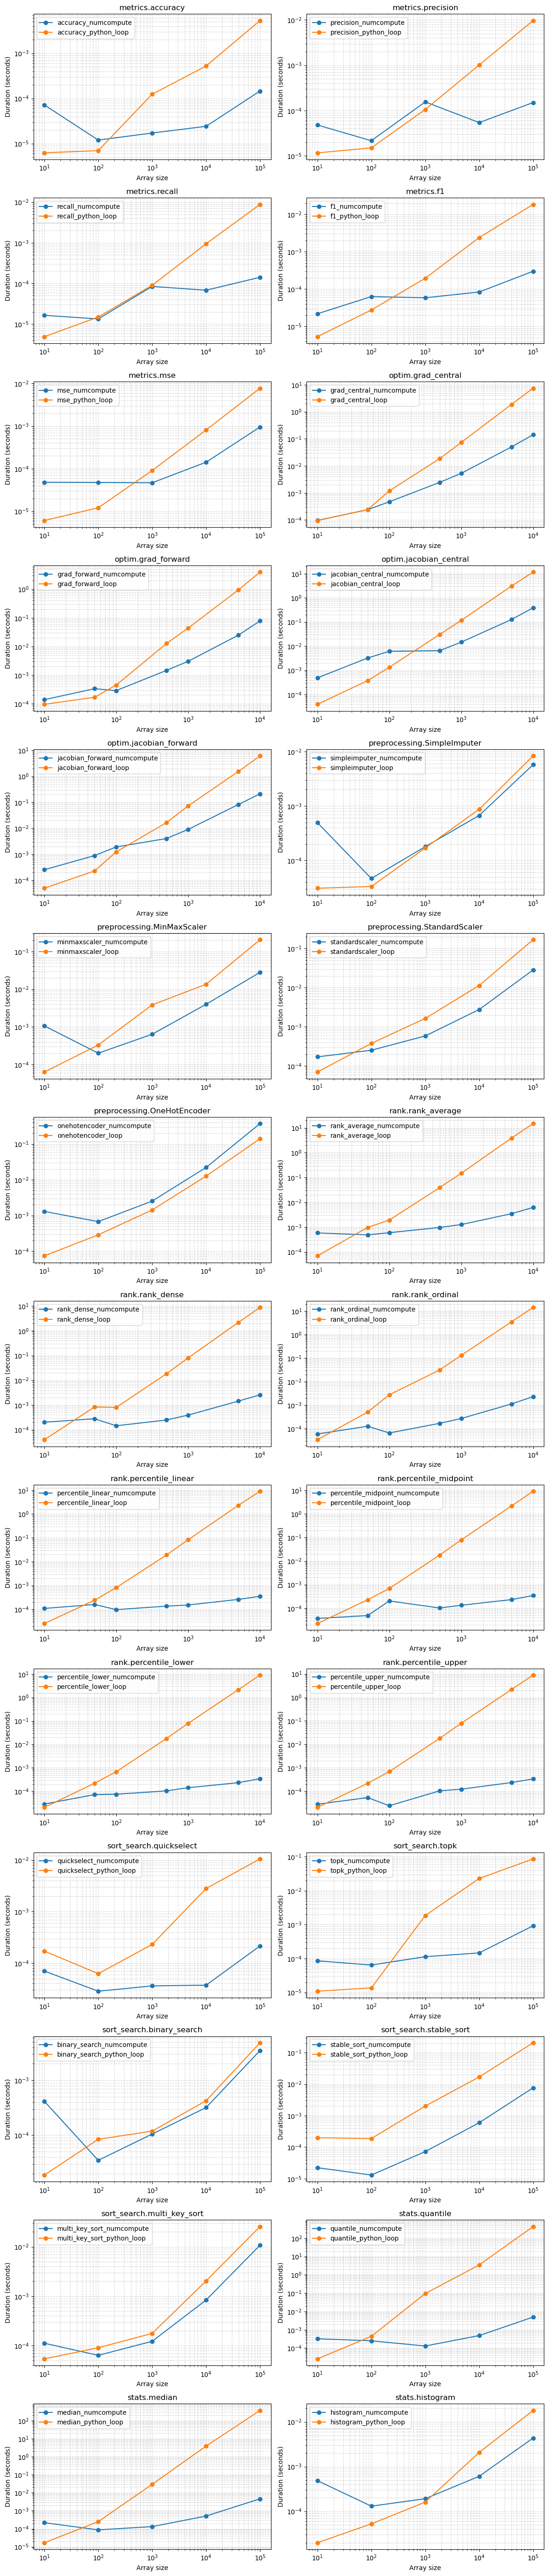

In [8]:
df = pd.concat(
    [load_results(f) for f in glob.glob('../benchmark/benchmark_results_*.jsonl')],
    ignore_index=True,
)
pivot = make_pivot(df)
plot_pairs(pivot, functions)